# Diabetes VAE — Baseline Training

Self-contained Kaggle notebook. Preprocesses MetaboNet parquet data and trains a
baseline convolutional VAE on CGM (continuous glucose monitoring) time series.

**Before running:**
1. Add your MetaboNet dataset to this notebook via *Add data*
2. Set `DATASET_SLUG` in the next cell to match your dataset's slug
3. Enable GPU: *Settings → Accelerator → GPU T4 x2*

In [29]:
!pip install umap-learn pyarrow -q

In [1]:
 import os
for root, dirs, files in os.walk('/kaggle/input'):                                             
  for f in files:                                       
      print(os.path.join(root, f))

/kaggle/input/datasets/cristinasobrino/metabonet/train.parquet
/kaggle/input/datasets/cristinasobrino/metabonet/test.parquet


In [2]:
# ── Configure this ──────────────────────────────────────────────────────────
DATASET_SLUG = 'datasets/cristinasobrino/metabonet'   # slug of the Kaggle dataset containing the parquet files
# ────────────────────────────────────────────────────────────────────────────

from pathlib import Path

INPUT_DIR = Path(f'/kaggle/input/{DATASET_SLUG}')
WORK_DIR  = Path('/kaggle/working')
PROC_DIR  = WORK_DIR / 'data' / 'processed'
MODEL_DIR = WORK_DIR / 'models'

PROC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input dir:  {INPUT_DIR}')
print(f'Processed:  {PROC_DIR}')
print(f'Models:     {MODEL_DIR}')
print(f'train.parquet exists: {(INPUT_DIR / "train.parquet").exists()}')
print(f'test.parquet  exists: {(INPUT_DIR / "test.parquet").exists()}')

Input dir:  /kaggle/input/datasets/cristinasobrino/metabonet
Processed:  /kaggle/working/data/processed
Models:     /kaggle/working/models
train.parquet exists: True
test.parquet  exists: True


## 1. Preprocessing

Streams through the parquet files and builds per-patient-day arrays:
- `cgm.npy` — (N, 288) glucose readings at 5-min intervals, linearly interpolated
- `insulin.npy` — (N, 288) insulin units
- `physiology.npy` — (N, 5) daily summaries: HR, steps, GSR, skin temp, calories
- `metadata.parquet` — patient_id, date, demographics

In [3]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from tqdm import tqdm

PHYSIOLOGY_COLS = ['heartrate', 'steps', 'galvanic_skin_response', 'skin_temp', 'calories_burned']
SLOTS_PER_DAY   = 288  # 24h * 60min / 5min


def slot_index(timestamps):
    return (timestamps.dt.hour * 60 + timestamps.dt.minute) // 5


def interpolate_cgm(arr):
    s = pd.Series(arr)
    s = s.interpolate(method='linear', limit=12)  # fill gaps up to 1 hour
    s = s.ffill().bfill()
    return s.values.astype(np.float32)


def process_parquet(path, min_cgm_fraction=0.5, batch_size=1_000_000):
    days = {}
    pf   = pq.ParquetFile(path)
    total_rows = pf.metadata.num_rows
    print(f'  {path.name}: {total_rows:,} rows, {pf.metadata.num_row_groups} row groups')

    for batch in tqdm(pf.iter_batches(batch_size=batch_size),
                      desc=f'  {path.stem}', total=total_rows // batch_size + 1):
        df = batch.to_pandas()
        df['_day']  = df['date'].dt.date
        df['_slot'] = slot_index(df['date']).clip(0, SLOTS_PER_DAY - 1)

        for (pid, day), grp in df.groupby(['id', '_day'], sort=False):
            key = (pid, day)
            if key not in days:
                row0 = grp.iloc[0]
                days[key] = {
                    'cgm':        np.full(SLOTS_PER_DAY, np.nan, dtype=np.float32),
                    'insulin':    np.zeros(SLOTS_PER_DAY, dtype=np.float32),
                    'phys_sum':   np.zeros(len(PHYSIOLOGY_COLS), dtype=np.float64),
                    'phys_count': np.zeros(len(PHYSIOLOGY_COLS), dtype=np.int32),
                    'n_cgm':      0,
                    'patient_id': pid,
                    'date':       str(day),
                    'source_file': row0.get('source_file', ''),
                    'gender':     row0.get('gender', None),
                    'age':        row0.get('age', np.nan),
                }

            entry = days[key]
            slots = grp['_slot'].values.astype(int)

            cgm_vals = grp['CGM'].values.astype(np.float32)
            cgm_ok   = ~np.isnan(cgm_vals)
            if cgm_ok.any():
                entry['cgm'][slots[cgm_ok]] = cgm_vals[cgm_ok]
                entry['n_cgm'] += int(cgm_ok.sum())

            ins_vals = grp['insulin'].values
            ins_ok   = ~np.isnan(ins_vals)
            if ins_ok.any():
                entry['insulin'][slots[ins_ok]] = ins_vals[ins_ok].astype(np.float32)

            for j, col in enumerate(PHYSIOLOGY_COLS):
                if col in grp.columns:
                    vals = grp[col].dropna().values
                    if len(vals):
                        entry['phys_sum'][j]   += vals.sum()
                        entry['phys_count'][j] += len(vals)

    min_cgm = int(min_cgm_fraction * SLOTS_PER_DAY)
    kept    = [v for v in days.values() if v['n_cgm'] >= min_cgm]
    print(f'  Patient-days before filter: {len(days):,}  '
          f'after (>={min_cgm} CGM readings): {len(kept):,}')

    if not kept:
        raise RuntimeError('No patient-days passed the CGM coverage filter.')

    cgm_arr    = np.stack([interpolate_cgm(e['cgm']) for e in kept])
    insulin_arr = np.stack([e['insulin'] for e in kept])

    phys_arr = np.zeros((len(kept), len(PHYSIOLOGY_COLS)), dtype=np.float32)
    for i, e in enumerate(kept):
        with np.errstate(invalid='ignore'):
            mask = e['phys_count'] > 0
            phys_arr[i, mask]  = (e['phys_sum'][mask] / e['phys_count'][mask]).astype(np.float32)
        phys_arr[i, ~mask] = np.nan

    meta = pd.DataFrame({
        'patient_id':     [e['patient_id']    for e in kept],
        'date':           [e['date']           for e in kept],
        'source_file':    [e['source_file']    for e in kept],
        'n_cgm_readings': [e['n_cgm']          for e in kept],
        'gender':         [e['gender']         for e in kept],
        'age':            [e['age']            for e in kept],
    })

    return cgm_arr, insulin_arr, phys_arr, meta

print('Preprocessing functions ready.')

Preprocessing functions ready.


In [4]:
MIN_CGM_FRACTION = 0.5   # keep days with at least 50% CGM coverage (144/288 readings)
BATCH_SIZE       = 1_000_000

for split in ('train', 'test'):
    src = INPUT_DIR / f'{split}.parquet'
    if not src.exists():
        print(f'Skipping {split}: {src} not found')
        continue

    print(f'\nProcessing {split}...')
    out_dir = PROC_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)

    cgm, insulin, physiology, meta = process_parquet(src, MIN_CGM_FRACTION, BATCH_SIZE)

    np.save(out_dir / 'cgm.npy',       cgm)
    np.save(out_dir / 'insulin.npy',   insulin)
    np.save(out_dir / 'physiology.npy', physiology)
    meta.to_parquet(out_dir / 'metadata.parquet', index=False)

    print(f'  Saved to {out_dir}')
    print(f'  cgm:        {cgm.shape}')
    print(f'  insulin:    {insulin.shape}')
    print(f'  physiology: {physiology.shape}')
    print(f'  metadata:   {len(meta)} rows')

print('\nPreprocessing done.')


Processing train...
  train.parquet: 132,772,529 rows, 128 row groups


  train: 100%|██████████| 133/133 [08:08<00:00,  3.67s/it]


  Patient-days before filter: 437,098  after (>=144 CGM readings): 379,849
  Saved to /kaggle/working/data/processed/train
  cgm:        (379849, 288)
  insulin:    (379849, 288)
  physiology: (379849, 5)
  metadata:   379849 rows

Processing test...
  test.parquet: 22,069,548 rows, 736 row groups


  test: 100%|██████████| 23/23 [01:58<00:00,  5.17s/it]


  Patient-days before filter: 76,530  after (>=144 CGM readings): 69,894
  Saved to /kaggle/working/data/processed/test
  cgm:        (69894, 288)
  insulin:    (69894, 288)
  physiology: (69894, 5)
  metadata:   69894 rows

Preprocessing done.


## 2. Source Code

Config, model architecture, dataset, and training pipeline — inlined from `src/`.

In [5]:
import torch
import json
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from datetime import datetime
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


@dataclass
class DataConfig:
    cgm_resolution: int = 5
    cgm_readings_per_day: int = 288
    dataset_split: Dict = None
    def __post_init__(self):
        if self.dataset_split is None:
            self.dataset_split = {'train': 0.7, 'val': 0.15, 'test': 0.15}


@dataclass
class ModelConfig:
    latent_dim: int = 8
    cgm_seq_length: int = 288
    cgm_encoder_channels: List[int] = None
    cgm_encoder_kernel_size: int = 3
    cgm_encoder_stride: int = 1
    cgm_encoder_padding: int = 1
    cgm_decoder_channels: List[int] = None
    def __post_init__(self):
        if self.cgm_encoder_channels is None:
            self.cgm_encoder_channels = [16, 32, 64]
        if self.cgm_decoder_channels is None:
            self.cgm_decoder_channels = [64, 32, 16]


@dataclass
class TrainingConfig:
    batch_size: int = 64
    num_epochs: int = 100
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    kl_annealing_enabled: bool = True
    kl_warmup_epochs: int = 10
    kl_weight: float = 1.0
    num_workers: int = 2
    checkpoint_freq: int = 5


class Config:
    def __init__(self, data=None, model=None, training=None):
        self.data     = data     or DataConfig()
        self.model    = model    or ModelConfig()
        self.training = training or TrainingConfig()


def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        device = 'cuda'
        print(f'GPU: {torch.cuda.get_device_name(0)}')
    else:
        device = 'cpu'
        print('No GPU found, using CPU')
    return device


print('Config + utils ready.')

Config + utils ready.


In [6]:
import torch.nn as nn
import torch.nn.functional as F


class ConvEncoder1D(nn.Module):
    def __init__(self, input_length, channels, kernel_size=3, stride=1, padding=1, latent_dim=8):
        super().__init__()
        self.input_length = input_length
        layers = []
        in_ch  = 1
        current_length = input_length
        for out_ch in channels:
            layers += [nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding), nn.ReLU()]
            current_length = (current_length - kernel_size + 2 * padding) // stride + 1
            in_ch = out_ch
        self.conv_layers    = nn.Sequential(*layers)
        self.conv_out_size  = in_ch * current_length
        self.fc_mu          = nn.Linear(self.conv_out_size, latent_dim)
        self.fc_logvar      = nn.Linear(self.conv_out_size, latent_dim)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)


class ConvDecoder1D(nn.Module):
    def __init__(self, output_length, channels, latent_dim=8, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.output_length     = output_length
        self.conv_out_channels = channels[0]
        self.conv_out_length   = max(output_length // (2 ** len(channels)), 1)
        fc_out = self.conv_out_channels * self.conv_out_length
        self.fc = nn.Linear(latent_dim, fc_out)
        layers  = []
        in_ch   = channels[0]
        for out_ch in channels[1:] + [1]:
            layers.append(nn.ConvTranspose1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding))
            if out_ch != 1:
                layers.append(nn.ReLU())
            in_ch = out_ch
        self.deconv_layers = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), self.conv_out_channels, self.conv_out_length)
        x = self.deconv_layers(x).squeeze(1)
        if x.size(1) > self.output_length:
            x = x[:, :self.output_length]
        elif x.size(1) < self.output_length:
            x = F.pad(x, (0, self.output_length - x.size(1)))
        return x


class BaselineVAE(nn.Module):
    def __init__(self, cgm_length=288, encoder_channels=None, decoder_channels=None, latent_dim=8):
        super().__init__()
        encoder_channels = encoder_channels or [16, 32, 64]
        decoder_channels = decoder_channels or [64, 32, 16]
        self.encoder   = ConvEncoder1D(cgm_length, encoder_channels, latent_dim=latent_dim)
        self.decoder   = ConvDecoder1D(cgm_length, decoder_channels, latent_dim=latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, cgm):
        mu, logvar  = self.encoder(cgm)
        z           = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def encode(self, cgm):
        mu, logvar = self.encoder(cgm)
        return self.reparameterize(mu, logvar)


print('Model architecture ready.')

Model architecture ready.


In [7]:
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler


class MetaboNetDataset(Dataset):
    def __init__(self, processed_dir, split='train', normalize=True):
        self.split_dir = Path(processed_dir) / split
        self.normalize = normalize
        if not self.split_dir.exists():
            raise FileNotFoundError(f'Processed data not found: {self.split_dir}')
        self._load()
        self.scalers = {}
        if normalize:
            self._fit_scalers()

    def _load(self):
        self.cgm_data        = np.load(self.split_dir / 'cgm.npy',        mmap_mode='r')
        self.insulin_data    = np.load(self.split_dir / 'insulin.npy',    mmap_mode='r')
        self.physiology_data = np.load(self.split_dir / 'physiology.npy', mmap_mode='r')
        self.metadata        = pd.read_parquet(self.split_dir / 'metadata.parquet')
        self.n_samples       = len(self.cgm_data)

    def _fit_scalers(self):
        cgm_fit = np.array(self.cgm_data,        dtype=np.float32)
        ins_fit = np.array(self.insulin_data,     dtype=np.float32)
        phy_fit = np.array(self.physiology_data,  dtype=np.float32)
        phy_obs = phy_fit[~np.isnan(phy_fit).any(axis=1)]
        self.scalers['cgm']     = StandardScaler().fit(cgm_fit)
        self.scalers['insulin'] = StandardScaler().fit(ins_fit)
        if len(phy_obs):
            self.scalers['physiology'] = StandardScaler().fit(phy_obs)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        cgm = np.array(self.cgm_data[idx], dtype=np.float32)
        if self.normalize and 'cgm' in self.scalers:
            cgm = self.scalers['cgm'].transform(cgm.reshape(1, -1)).flatten()

        insulin = np.array(self.insulin_data[idx], dtype=np.float32)
        if self.normalize and 'insulin' in self.scalers:
            insulin = self.scalers['insulin'].transform(insulin.reshape(1, -1)).flatten()

        phys = np.array(self.physiology_data[idx], dtype=np.float32)
        if np.isnan(phys).any():
            phys = np.zeros(phys.shape, dtype=np.float32)
        elif self.normalize and 'physiology' in self.scalers:
            phys = self.scalers['physiology'].transform(phys.reshape(1, -1)).flatten()

        row = self.metadata.iloc[idx]
        return {
            'cgm':        torch.from_numpy(cgm),
            'insulin':    torch.from_numpy(insulin),
            'physiology': torch.from_numpy(phys),
            'patient_id': row['patient_id'],
            'date':       row['date'],
        }

print('Dataset class ready.')

Dataset class ready.


In [8]:
import torch.optim as optim
from torch.utils.data import DataLoader


class VAETrainer:
    def __init__(self, model, device, learning_rate=3e-4, weight_decay=1e-5):
        self.model     = model.to(device)
        self.device    = device
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        self.history   = {'train_loss': [], 'train_recon': [], 'train_kl': [],
                          'val_loss':   [], 'val_recon':   [], 'val_kl':   []}

    def _vae_loss(self, recon, target, mu, logvar, kl_weight):
        recon_loss = nn.MSELoss(reduction='mean')(recon, target)
        logvar     = logvar.clamp(-10, 10)
        kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

    def _kl_weight(self, epoch, warmup_epochs):
        return min(1.0, epoch / warmup_epochs) if warmup_epochs > 0 else 1.0

    def _run_epoch(self, loader, epoch, total_epochs, kl_weight, train=True):
        self.model.train(train)
        total_loss = total_recon = total_kl = 0.0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for batch in tqdm(loader, desc=f'  Epoch {epoch+1}/{total_epochs} [{"train" if train else "val  "}]',
                              leave=False):
                cgm = batch['cgm'].to(self.device)
                recon, mu, logvar = self.model(cgm)
                loss, rl, kl = self._vae_loss(recon, cgm, mu, logvar, kl_weight)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total_loss  += loss.item()
                total_recon += rl.item()
                total_kl    += kl.item()
        n = len(loader)
        return total_loss / n, total_recon / n, total_kl / n

    def fit(self, train_loader, val_loader, epochs, kl_annealing=True,
            warmup_epochs=10, save_dir='models', save_freq=5):
        save_dir    = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        best_val    = float('inf')

        for epoch in range(epochs):
            kw = self._kl_weight(epoch, warmup_epochs) if kl_annealing else 1.0
            tl, tr, tk = self._run_epoch(train_loader, epoch, epochs, kw, train=True)
            vl, vr, vk = self._run_epoch(val_loader,   epoch, epochs, kw, train=False)

            self.history['train_loss'].append(tl);  self.history['train_recon'].append(tr)
            self.history['train_kl'].append(tk);    self.history['val_loss'].append(vl)
            self.history['val_recon'].append(vr);   self.history['val_kl'].append(vk)

            print(f'Epoch {epoch+1:3d}/{epochs}  '
                  f'train loss={tl:.4f} recon={tr:.4f} kl={tk:.4f}  '
                  f'val loss={vl:.4f} recon={vr:.4f} kl={vk:.4f}  kl_w={kw:.3f}')

            if (epoch + 1) % save_freq == 0:
                ckpt = {'epoch': epoch, 'model_state': self.model.state_dict(),
                        'optimizer_state': self.optimizer.state_dict(), 'history': self.history}
                torch.save(ckpt, save_dir / f'checkpoint_epoch_{epoch+1:03d}.pt')

            if vl < best_val:
                best_val = vl
                torch.save(self.model.state_dict(), save_dir / 'best_model.pt')
                print(f'  -> New best model (val={best_val:.4f})')

        self._plot(save_dir / 'loss_curves.png')
        with open(save_dir / 'training_history.json', 'w') as f:
            json.dump(self.history, f, indent=2)
        print(f'Training complete. Best val loss: {best_val:.4f}')

    def _plot(self, path):
        epochs = range(1, len(self.history['train_loss']) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, key, title in zip(axes,
                                   ['loss', 'recon', 'kl'],
                                   ['Total loss', 'Reconstruction loss', 'KL divergence']):
            ax.plot(epochs, self.history[f'train_{key}'], label='train')
            ax.plot(epochs, self.history[f'val_{key}'],   label='val')
            ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
        fig.tight_layout()
        fig.savefig(path, dpi=100)
        plt.close(fig)
        print(f'Loss curves saved to {path}')

print('Trainer ready.')

Trainer ready.


## 3. Train

Adjust the config below if needed, then run the cell.

In [9]:
from torch.utils.data import random_split

# ── Hyperparameters ──────────────────────────────────────────────────────────
cfg = Config(
    model    = ModelConfig(latent_dim=8,
                           cgm_encoder_channels=[16, 32, 64],
                           cgm_decoder_channels=[64, 32, 16]),
    training = TrainingConfig(batch_size=64,
                              num_epochs=100,
                              learning_rate=3e-4,
                              kl_annealing_enabled=True,
                              kl_warmup_epochs=10,
                              checkpoint_freq=5,
                              num_workers=2),
)
# ─────────────────────────────────────────────────────────────────────────────

In [ ]:
set_seed(42)
device = get_device()

print('Loading datasets...')
train_set = MetaboNetDataset(PROC_DIR, split='train', normalize=True)
test_set  = MetaboNetDataset(PROC_DIR, split='test',  normalize=True)

val_n   = int(0.15 * len(train_set))
train_n = len(train_set) - val_n
train_set, val_set = random_split(train_set, [train_n, val_n],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=cfg.training.batch_size,
                          shuffle=True,  num_workers=cfg.training.num_workers, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=cfg.training.batch_size,
                          shuffle=False, num_workers=cfg.training.num_workers, pin_memory=True)

print(f'Train: {len(train_set):,}  Val: {len(val_set):,}  Test: {len(test_set):,}')

model = BaselineVAE(
    cgm_length       = cfg.model.cgm_seq_length,
    encoder_channels = cfg.model.cgm_encoder_channels,
    decoder_channels = cfg.model.cgm_decoder_channels,
    latent_dim       = cfg.model.latent_dim,
)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

trainer = VAETrainer(model, device,
                     learning_rate=cfg.training.learning_rate,
                     weight_decay=cfg.training.weight_decay)

trainer.fit(
    train_loader   = train_loader,
    val_loader     = val_loader,
    epochs         = cfg.training.num_epochs,
    kl_annealing   = cfg.training.kl_annealing_enabled,
    warmup_epochs  = cfg.training.kl_warmup_epochs,
    save_dir       = str(MODEL_DIR),
    save_freq      = cfg.training.checkpoint_freq,
)

GPU: Tesla T4
Loading datasets...
Train: 322,872  Val: 56,977  Test: 69,894
Model parameters: 331,281


Epoch   1/100  train loss=0.8760 recon=0.8760 kl=6.9998  val loss=0.8783 recon=0.8783 kl=6.8900  kl_w=0.000
  -> New best model (val=0.8783)


Epoch   2/100  train loss=0.9151 recon=0.8934 kl=0.2169  val loss=0.9163 recon=0.8956 kl=0.2076  kl_w=0.100


Epoch   3/100  train loss=0.9296 recon=0.9025 kl=0.1355  val loss=0.9333 recon=0.9069 kl=0.1319  kl_w=0.200


Epoch   4/100  train loss=0.9412 recon=0.9104 kl=0.1024  val loss=0.9446 recon=0.9131 kl=0.1050  kl_w=0.300


...

Epoch  96/100  train loss=0.9837 recon=0.9486 kl=0.0351  val loss=0.9871 recon=0.9528 kl=0.0343  kl_w=1.000


Epoch  97/100  train loss=0.9839 recon=0.9487 kl=0.0352  val loss=0.9873 recon=0.9524 kl=0.0350  kl_w=1.000


Epoch  98/100  train loss=0.9837 recon=0.9487 kl=0.0350  val loss=0.9871 recon=0.9529 kl=0.0342  kl_w=1.000


Epoch  99/100  train loss=0.9836 recon=0.9486 kl=0.0350  val loss=0.9872 recon=0.9530 kl=0.0342  kl_w=1.000


Epoch 100/100  train loss=0.9836 recon=0.9487 kl=0.0349  val loss=0.9872 recon=0.9520 kl=0.0351  kl_w=1.000
Loss curves saved to /kaggle/working/models/loss_curves.png
Training complete. Best val loss: 0.8783


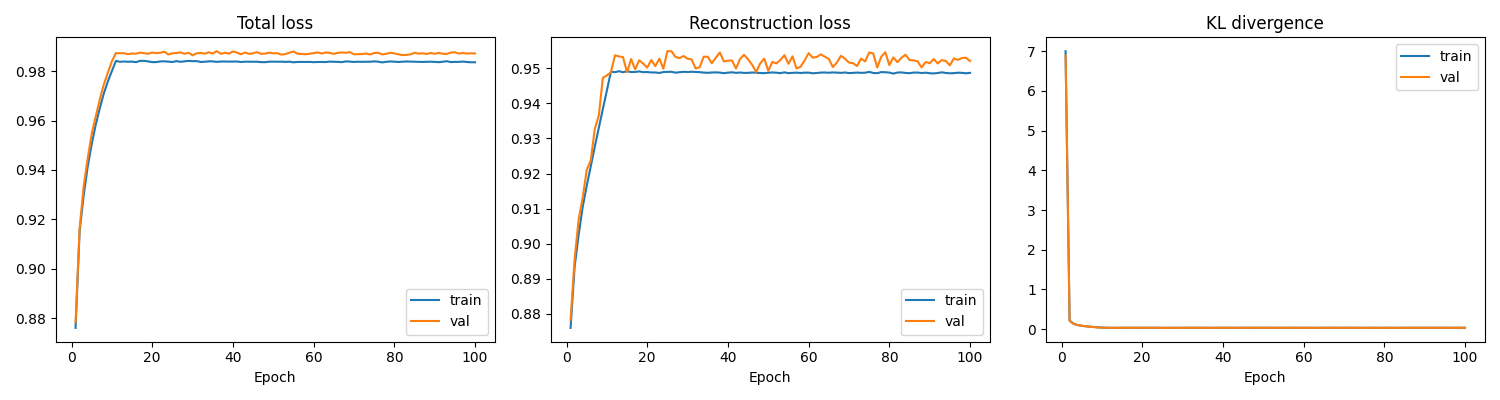

In [39]:
from IPython.display import Image
Image(str(MODEL_DIR / 'loss_curves.png'))

# 5. Evaluation

In [39]:
import json, torch
from pathlib import Path                                                                       
                                                        
WORK_DIR  = Path('/kaggle/working')
MODEL_DIR = WORK_DIR / 'models'                                                                
WARMUP_EPOCHS = 10  # same value used during training
                                                        
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the full loss history                
with open(MODEL_DIR / 'training_history.json') as f:                                           
  history = json.load(f)
                                                                                             
val_losses = history['val_loss']  # index = epoch - 1
                                                                                             
# Find best epoch after warmup, among saved checkpoints only (every 5 epochs)
saved_epochs = sorted([                                                                        
  int(p.stem.split('_')[-1])              
  for p in MODEL_DIR.glob('checkpoint_epoch_*.pt')                                           
])              
                                                                                             
candidates = [(ep, val_losses[ep - 1]) for ep in saved_epochs if ep > WARMUP_EPOCHS]
best_epoch, best_loss = min(candidates, key=lambda x: x[1])                                    
                                          
print(f'Available checkpoints: {saved_epochs}')                                                
print(f'Best post-warmup checkpoint: epoch {best_epoch}  val_loss={best_loss:.4f}')
                                                                                             
# Load it                               
ckpt = torch.load(MODEL_DIR / f'checkpoint_epoch_{best_epoch:03d}.pt', map_location=device)    
model_eval.load_state_dict(ckpt['model_state'])    
model_eval = model_eval.to(device)   # ← this line was missing
model_eval.eval()                       
print('Model loaded.') 

Available checkpoints: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Best post-warmup checkpoint: epoch 30  val_loss=0.9864
Model loaded.


In [27]:
import json
import matplotlib.pyplot as plt

In [35]:
with open(MODEL_DIR / 'training_history.json') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
                           ['loss', 'recon', 'kl'],
                           ['Total loss (ELBO)', 'Reconstruction MSE', 'KL divergence']):
    ax.plot(epochs, history[f'train_{key}'], label='train')
    ax.plot(epochs, history[f'val_{key}'],   label='val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
fig.tight_layout()
plt.show()

In [40]:
model_eval = BaselineVAE(
    cgm_length       = cfg.model.cgm_seq_length,
    encoder_channels = cfg.model.cgm_encoder_channels,
    decoder_channels = cfg.model.cgm_decoder_channels,
    latent_dim       = cfg.model.latent_dim,
)


In [42]:
# Pick 6 random test samples and overlay original vs reconstructed
model_eval = model_eval.to(device)
set_seed(0)
with torch.no_grad():
    sample_loader = DataLoader(test_set, batch_size=6, shuffle=True)
    batch = next(iter(sample_loader))
    cgm_orig = batch['cgm'].to(device)
    recon, mu, logvar = model_eval(cgm_orig)

cgm_np   = cgm_orig.cpu().numpy()
recon_np = recon.cpu().numpy()
time_h   = np.arange(288) * 5 / 60  # 5-min slots -> hours

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(time_h, cgm_np[i],   label='original',      alpha=0.85, linewidth=1.2)
    ax.plot(time_h, recon_np[i], label='reconstructed', alpha=0.85, linewidth=1.2, linestyle='--')
    pid  = batch['patient_id'][i]
    date = batch['date'][i]
    mse  = float(((cgm_np[i] - recon_np[i]) ** 2).mean())
    ax.set_title(f'Patient {pid} | {date}\nMSE={mse:.4f}')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('CGM (normalised)')
    ax.legend(fontsize=8)

fig.suptitle('Reconstruction quality — 6 test samples', fontsize=13)
fig.tight_layout()
plt.savefig(MODEL_DIR / 'reconstructions.png', dpi=100)
plt.show()

In [43]:
# Full test-set reconstruction MSE
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)
total_mse = 0.0

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        cgm = batch['cgm'].to(device)
        recon, mu, logvar = model_eval(cgm)
        total_mse += nn.MSELoss()(recon, cgm).item()

print(f'Test reconstruction MSE: {total_mse / len(test_loader):.6f}')

Test inference: 100%|██████████| 274/274 [00:23<00:00, 11.66it/s]

Test reconstruction MSE: 1.022357


In [45]:
import umap

# Encode every test sample — use mu (deterministic) for the visualisation
all_mu, all_pids = [], []
with torch.no_grad():
    for batch in tqdm(DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2),
                      desc='Encoding'):
        cgm = batch['cgm'].to(device)
        mu, _ = model_eval.encoder(cgm)
        all_mu.append(mu.cpu().numpy())
        all_pids.extend(batch['patient_id'])

Z   = np.vstack(all_mu)          # (N, latent_dim)
pids = np.array(all_pids)
print(f'Latent matrix: {Z.shape}')

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z2d = reducer.fit_transform(Z)

# Plot — one colour per patient
unique_pids = np.unique(pids)
cmap = plt.cm.get_cmap('tab20', len(unique_pids))
fig, ax = plt.subplots(figsize=(10, 8))
for i, pid in enumerate(unique_pids):
    mask = pids == pid
    ax.scatter(Z2d[mask, 0], Z2d[mask, 1], s=5, alpha=0.5, color=cmap(i), label=str(pid))

ax.set_title('Latent space UMAP — test set (coloured by patient)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
if len(unique_pids) <= 20:
    ax.legend(markerscale=3, fontsize=8, title='Patient', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout()
plt.savefig(MODEL_DIR / 'umap_latent_space.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Unique patients in test set: {len(unique_pids)}')

Encoding: 100%|██████████| 274/274 [00:23<00:00, 11.73it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Latent matrix: (69894, 8)


/tmp/ipykernel_57/3359510454.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_pids))


Unique patients in test set: 305


### Proxy-free metrics

These two checks don't require clinical labels — only patient IDs and dates.

- **Silhouette score** — how well the latent space separates patients (1 = perfect, 0 = random)
- **Temporal consistency** — are consecutive days for the same patient closer in latent space than random pairs?

In [46]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

# Z and pids were computed in the UMAP cell
le     = LabelEncoder()
labels = le.fit_transform(pids)

if len(np.unique(labels)) < 2:
    print('Need at least 2 patients to compute silhouette score.')
else:
    # Silhouette is O(N^2) — subsample if large
    MAX_N = 5000
    if len(Z) > MAX_N:
        idx      = np.random.default_rng(42).choice(len(Z), MAX_N, replace=False)
        Z_s, L_s = Z[idx], labels[idx]
    else:
        Z_s, L_s = Z, labels

    score = silhouette_score(Z_s, L_s, metric='euclidean')
    print(f'Silhouette score (patient separation in latent space): {score:.4f}')
    print(f'  >0.50        strong separation')
    print(f'  0.25 – 0.50  moderate')
    print(f'  <0.25        weak / mixed')

Silhouette score (patient separation in latent space): -0.3020
  >0.50        strong separation
  0.25 – 0.50  moderate
  <0.25        weak / mixed


In [47]:
# Are consecutive days for a patient closer in latent space than random pairs?
# Z[i] aligns with test_set.metadata.iloc[i] (DataLoader used shuffle=False)

meta = test_set.metadata.reset_index(drop=True)
rng  = np.random.default_rng(42)

adj_dists, rand_dists = [], []

for pid in np.unique(pids):
    mask  = pids == pid
    idx   = np.where(mask)[0]
    order = np.argsort(meta.loc[idx, 'date'].values)
    zs    = Z[idx][order]   # patient days sorted by date

    if len(zs) < 2:
        continue

    for i in range(len(zs) - 1):
        adj_dists.append(np.linalg.norm(zs[i] - zs[i + 1]))

    for _ in range(len(zs) - 1):   # equal number of random pairs
        i, j = rng.choice(len(zs), size=2, replace=False)
        rand_dists.append(np.linalg.norm(zs[i] - zs[j]))

adj_mean  = float(np.mean(adj_dists))
rand_mean = float(np.mean(rand_dists))

print(f'Adjacent day distance:  {adj_mean:.4f}')
print(f'Random pair distance:   {rand_mean:.4f}')
print(f'Ratio (adj / random):   {adj_mean / rand_mean:.3f}  (lower = more temporally smooth)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(adj_dists,  bins=50, alpha=0.6, label=f'Adjacent days  (mean={adj_mean:.3f})')
ax.hist(rand_dists, bins=50, alpha=0.6, label=f'Random pairs   (mean={rand_mean:.3f})')
ax.set_xlabel('Euclidean distance in latent space')
ax.set_ylabel('Count')
ax.set_title('Temporal consistency')
ax.legend()
fig.tight_layout()
plt.savefig(MODEL_DIR / 'temporal_consistency.png', dpi=100)
plt.show()

Adjacent day distance:  0.1167
Random pair distance:   0.1232
Ratio (adj / random):   0.947  (lower = more temporally smooth)


In [48]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import LabelEncoder

le     = LabelEncoder()
labels = le.fit_transform(pids)

if len(np.unique(labels)) < 2:
    print('Need at least 2 patients to compute silhouette score.')
else:
    MAX_N = 5000
    if len(Z) > MAX_N:
        idx      = np.random.default_rng(42).choice(len(Z), MAX_N, replace=False)
        Z_s, L_s = Z[idx], labels[idx]
    else:
        Z_s, L_s = Z, labels

    score       = silhouette_score(Z_s, L_s, metric='euclidean')
    sil_samples = silhouette_samples(Z_s, L_s, metric='euclidean')

    print(f'Silhouette score (patient separation): {score:.4f}')
    print(f'  >0.50        strong')
    print(f'  0.25 – 0.50  moderate')
    print(f'  <0.25        weak / mixed')

    # Per-patient bar chart
    pid_labels_s   = le.inverse_transform(L_s)
    df_sil         = pd.DataFrame({'patient': pid_labels_s, 'silhouette': sil_samples})
    patient_scores = df_sil.groupby('patient')['silhouette'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(patient_scores) * 0.5), 5))
    colors = ['steelblue' if s > 0 else 'tomato' for s in patient_scores.values]
    ax.bar(range(len(patient_scores)), patient_scores.values, color=colors)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axhline(score, color='orange', linewidth=1.5, linestyle='--', label=f'overall mean={score:.3f}')
    ax.set_xticks(range(len(patient_scores)))
    ax.set_xticklabels(patient_scores.index, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Patient')
    ax.set_ylabel('Mean silhouette score')
    ax.set_title('Per-patient silhouette scores  (blue=well separated, red=mixed)')
    ax.legend()
    fig.tight_layout()
    plt.savefig(MODEL_DIR / 'silhouette_per_patient.png', dpi=100)
    plt.show()

Silhouette score (patient separation): -0.3020
  >0.50        strong
  0.25 – 0.50  moderate
  <0.25        weak / mixed


In [49]:
# Temporal consistency: adjacent days vs random pairs
# Z[i] aligns with test_set.metadata.iloc[i] (DataLoader shuffle=False)

meta = test_set.metadata.reset_index(drop=True)
rng  = np.random.default_rng(42)

adj_dists, rand_dists = [], []

for pid in np.unique(pids):
    mask  = pids == pid
    idx   = np.where(mask)[0]
    order = np.argsort(meta.loc[idx, 'date'].values)
    zs    = Z[idx][order]

    if len(zs) < 2:
        continue

    for i in range(len(zs) - 1):
        adj_dists.append(np.linalg.norm(zs[i] - zs[i + 1]))

    for _ in range(len(zs) - 1):
        i, j = rng.choice(len(zs), size=2, replace=False)
        rand_dists.append(np.linalg.norm(zs[i] - zs[j]))

adj_mean  = float(np.mean(adj_dists))
rand_mean = float(np.mean(rand_dists))

print(f'Adjacent day distance:  {adj_mean:.4f}')
print(f'Random pair distance:   {rand_mean:.4f}')
print(f'Ratio (adj / random):   {adj_mean / rand_mean:.3f}  (lower = more temporally smooth)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(adj_dists,  bins=50, alpha=0.6, label=f'Adjacent days  (mean={adj_mean:.3f})')
ax.hist(rand_dists, bins=50, alpha=0.6, label=f'Random pairs   (mean={rand_mean:.3f})')
ax.set_xlabel('Euclidean distance in latent space')
ax.set_ylabel('Count')
ax.set_title('Temporal consistency')
ax.legend()
fig.tight_layout()
plt.savefig(MODEL_DIR / 'temporal_consistency.png', dpi=100)
plt.show()

# ── Latent trajectories for individual patients in UMAP space ────────────────
# Uses Z2d from the UMAP cell above

N_SHOW = min(6, len(np.unique(pids)))
show_pids = np.unique(pids)[:N_SHOW]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, pid in zip(axes.flat, show_pids):
    mask  = pids == pid
    idx   = np.where(mask)[0]
    dates = meta.loc[idx, 'date'].values
    order = np.argsort(dates)
    xy    = Z2d[idx][order]
    n     = len(xy)
    cvals = np.linspace(0, 1, n)

    for i in range(n - 1):
        color = plt.cm.coolwarm(cvals[i])
        ax.plot(xy[i:i+2, 0], xy[i:i+2, 1], color=color, alpha=0.7, linewidth=1.5)

    ax.scatter(xy[:, 0], xy[:, 1], c=cvals, cmap='coolwarm', s=20, zorder=5)
    ax.scatter(*xy[0],  color='green', s=90, zorder=6, marker='^', label='start')
    ax.scatter(*xy[-1], color='red',   s=90, zorder=6, marker='s', label='end')
    ax.set_title(f'Patient {pid}  ({n} days)')
    ax.legend(fontsize=7)

fig.suptitle('Latent trajectories in UMAP space — blue=early, red=late', fontsize=13)
fig.tight_layout()
plt.savefig(MODEL_DIR / 'latent_trajectories.png', dpi=100)
plt.show()

Adjacent day distance:  0.1167
Random pair distance:   0.1232
Ratio (adj / random):   0.947  (lower = more temporally smooth)
